In [ ]:
import pandas as pd
import json
import sys
import random
import numpy as np
sys.path.append("../src/")
from auxiliar_functions import *

# Contexto

Estás trabajando con Magic Help, un agente conversacional impulsado por IA diseñado para ayudar a los usuarios con consultas técnicas, solicitudes de código y soporte general. El sistema funciona mediante un flujo estructurado de nodos que enrutan las conversaciones según la intención del usuario y las respuestas del sistema.

# Planteamiento del problema

Queremos analizar nuestro agente conversacional para entender si los usuarios están siguiendo el flujo de conversación deseado o si están divergiendo en algún punto. 

**El objetivo es proporcionar hallazgos accionables que puedan ayudar a mejorar la lógica de enrutamiento del agente conversacional, identificar patrones de interacción problemáticos y mejorar la experiencia del usuario.**

# Read data

El dataset contiene datos de conversaciones con las columnas:

* `CONVERSATION_ID`: Identificador único de cada conversación.

* `CONV_LAST_UPDATED_DTTM`: Marca de tiempo de la última
actualización.

* `HISTORY_MESSAGES`: Cadena JSON que contiene el historial completo de la conversación (mensajes del usuario y del asistente).

* `LAST_NODE_ID`: El nodo donde terminó la conversación.

* `LAST_NODE_TYPE`: El tipo de nodo donde terminó la conversación.

* `NEXT_NODE_ID`: El nodo al que se estaba enrutando la conversación (si aplica).

* `CONV_SECONDS`: Duración de la conversación.

* `HISTORY_MESSAGES`: contiene un arreglo JSON de objetos de mensaje, cada uno con:
     - role: “user” o “assistant”
    - text: El contenido del mensaje
    - metadata: Metadatos adicionales, incluido el tipo de mensaje

In [2]:
FILE_PATH = "../data/magic_data_raw.csv"
processed_data = process_magic_data(file_path = FILE_PATH)
# long the data for display one row per message
exploded_data = explode_messages(processed_data)


In [4]:
processed_data['CONVERSATION'].values[0]

{'context_id': '7211ff57c07fd09eca5769040e7a1c9e',
 'identity': 'johnsonjoshua',
 'last_node': 'magic_help_guide',
 'last_speaker': 'magic_help_guide',
 'navigation': {'callers': {}, 'current_parent': ''},
 'node': 'magic_help_skill_eval',
 'path': 'init, user_data, user_metric, genai_learning_path_status, user_skills, context_magic_help, tone_magic_help, user_classifier, magic_help_guide',
 'private_context': {},
 'security_context_id': 'ebc8db73b9326fa0d79a120efa8a3e4d338a677c',
 'skill': {'name': 'magic_help_skill', 'version': '55'},
 'status': 'WAITING_NODES'}

In [6]:
processed_data['HISTORY_MESSAGES'].values[0]

[{'role': 'assistant',
  'text': 'Olá, Carlos! 👋 Eu sou o Magic Help, seu assistente para tudo relacionado ao Magic e GenAI aqui no Oz_land.\n\nNotei que você está começando a explorar o Magic, ainda sem criar ou atualizar Skills, mas já utiliza algumas ferramentas de GenAI no dia a dia. Caso esteja só conhecendo a plataforma ou pensando em desenvolver algo, posso te explicar os conceitos básicos, indicar um curso rápido, ou mostrar exemplos práticos!\n\nVocê está em fase de exploração ou já tem uma ideia de negócio/processo que gostaria de automatizar com o Magic? 😊',
  'conversation_id': '68311825-3b75-1ece-0ce6-611d71e8164d',
  'metadata': {'node_id': 'magic_help_guide',
   'timestamp': '2025-11-13 18:02:21',
   'type': 'message'}}]

### Long duration time in a conversation

In [91]:
get_conv(processed_data = processed_data, 
        conv_id = '6cdf38f4-c31e-e4e2-f292-2a95a77bb176')	

Conversation ID: 6cdf38f4-c31e-e4e2-f292-2a95a77bb176
User alias: maria95
Conversation path: init, user_data, user_metric, genai_learning_path_status, user_skills, context_magic_help, tone_magic_help, user_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_guide
Conversation length: 7
Conversation duration: 9643 seconds


[{'role': 'assistant',
  'text': 'Olá, Pedro! 👋 Sou o Magic Help, seu assistente para dúvidas sobre a plataforma Magic e tudo relacionado a GenAI aqui no Oz_land.\n\nNotei que você tem experimentado a Magic algumas vezes — isso é ótimo para explorar novas formas de trabalhar com inteligência artificial! Até agora, você ainda não criou Skills ou Agents, então posso ajudar na sua primeira criação ou explicar os conceitos básicos da plataforma.\n\nVocê está apenas conhecendo a Magic ou já tem algum caso de uso em mente que gostaria de automatizar? Me conte para eu te guiar melhor! 😊',
  'conversation_id': '6cdf38f4-c31e-e4e2-f292-2a95a77bb176',
  'metadata': {'has_next': False,
   'idx': 1,
   'node_id': 'magic_help_guide',
   'timestamp': '2025-10-15 17:42:30',
   'type': 'message'}},
 {'role': 'user',
  'text': 'Me explique conteúdos básicos da plataforma',
  'conversation_id': '6cdf38f4-c31e-e4e2-f292-2a95a77bb176',
  'metadata': {'timestamp': '2025-10-15 18:37:59', 'type': 'message'}}

# Analyze examples for each `LAST_NODE_ID` category

`LAST_NODE_ID`: El nodo donde terminó la conversación.


In [ ]:
processed_data['LAST_NODE_ID'].value_counts()

LAST_NODE_ID
magic_help_guide          13822
magic_help_skill_error     1820
feedback                     95
goodbye_magic_help           55
magic_help_skill_eval         5
Name: count, dtype: int64

In [201]:
# example where LAST_NODE_ID = magic_help_guide
fd = processed_data[processed_data['LAST_NODE_ID'] == 'magic_help_guide']
get_conv(processed_data = processed_data, 
        conv_id = fd['CONVERSATION_ID'].sample(1).values[0])

Conversation ID: a37fb89a-985a-ab5c-f1fe-141acaa004e9
User alias: denise20
Conversation path: init, user_data, user_metric, genai_learning_path_status, user_skills, context_magic_help, tone_magic_help, user_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_guide
Conversation length: 3
Conversation duration: 27 seconds
Next node: magic_help_skill_eval
Last node: magic_help_guide


[{'role': 'assistant',
  'text': '¡Hola, MAURO ALEJANDRO MISKOVIC! 👋 Soy Magic Help, tu asistente para todo lo relacionado con Magic y agentes de Generative AI en Oz_land.\n\nVeo que recién estás empezando a explorar este mundo y aún no creaste ningún Skill en Magic. ¿Querés saber más sobre qué podés hacer con la plataforma o necesitás ayuda para arrancar con alguna solución puntual? 🚀',
  'conversation_id': 'a37fb89a-985a-ab5c-f1fe-141acaa004e9',
  'metadata': {'has_next': False,
   'idx': 1,
   'node_id': 'magic_help_guide',
   'timestamp': '2025-10-02 00:09:53',
   'type': 'message'}},
 {'role': 'user',
  'text': 'mejorar en caso necesario el siguiente correo que envío previo a la apertura de un nuevo centro de logística, informando a la operación que desde sistemas estamos ok para operar\n\n"Buenas noches,\n\nLes compartimos el GO para la apertura del SVC de Concordia de parte de Internal Systems.\nComo riesgo nos queda el acceso por SIM Card al OpenGear, este se utiliza solo en ca

In [186]:
# example where LAST_NODE_ID = magic_help_skill_error
fd = processed_data[processed_data['LAST_NODE_ID'] == 'magic_help_skill_error']
get_conv(processed_data = processed_data, 
        conv_id = fd['CONVERSATION_ID'].sample(1).values[0])

Conversation ID: ed4b83bb-bd6f-3785-1cea-c582cc1ec0d9
User alias: eddie04
Conversation path: init, user_data, user_metric, genai_learning_path_status, user_skills, context_magic_help, tone_magic_help, user_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide, magic_help_skill_error
Conversation length: 4
Conversation duration: 465 seconds
Next node: __finish__
Last node: magic_help_skill_error


[{'role': 'assistant',
  'text': '¡Hola Carlos! 👋 Soy Magic Help, tu asistente para todo lo relacionado con Magic en Oz_land.\n\nVeo que has creado y actualizado varias *Skills*, como una llamada **aml_internal_reports**. 🚀 ¡Eso demuestra interés y avances en la plataforma!\n\n¿Te gustaría saber más sobre tus *Skills*, explorar nuevas funcionalidades de Magic, o tienes un caso concreto en el que necesitas ayuda? Cuéntame en qué etapa estás o qué necesitas lograr.',
  'conversation_id': 'ed4b83bb-bd6f-3785-1cea-c582cc1ec0d9',
  'metadata': {'has_next': False,
   'idx': 1,
   'node_id': 'magic_help_guide',
   'timestamp': '2025-09-24 23:53:10',
   'type': 'message'}},
 {'role': 'user',
  'text': 'tengo este error invalid_routing: invalid routing: node controlled routing (validate_api_response) is ambiguous : node_id was not set by node and multiple next_node_ids were defined: [response error',
  'conversation_id': 'ed4b83bb-bd6f-3785-1cea-c582cc1ec0d9',
  'metadata': {'timestamp': '2025-

In [ ]:
# example where LAST_NODE_ID = feedback
fd = processed_data[processed_data['LAST_NODE_ID'] == 'feedback']
get_conv(processed_data = processed_data, 
        conv_id = fd['CONVERSATION_ID'].sample(1).values[0])

Conversation ID: 8a691e51-c71c-0531-8045-5b4c3996be23
User alias: trose
Conversation path: init, user_data, user_metric, genai_learning_path_status, user_skills, context_magic_help, tone_magic_help, user_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, feedback
Conversation length: 11
Conversation duration: 609 seconds
Last node: magic_help_guide


[{'role': 'assistant',
  'text': '¡Hola, Giovanni! 👋 Soy Magic Help, tu asistente para todo lo relacionado con Magic en Oz_land.\n\nVeo que has creado y actualizado varias *Skills* (por ejemplo: "new_pdd_buyer_diagnostic" y "coherence_evaluator"), lo que demuestra un uso avanzado de la plataforma. 🚀\n\n¿Te gustaría explorar nuevas funcionalidades de Magic o necesitás ayuda específica desarrollando alguna *Skill*?',
  'conversation_id': '8a691e51-c71c-0531-8045-5b4c3996be23',
  'metadata': {'has_next': False,
   'idx': 1,
   'node_id': 'magic_help_guide',
   'timestamp': '2025-10-17 18:05:02',
   'type': 'message'}},
 {'role': 'user',
  'text': 'quiero hacer un api call con un get',
  'conversation_id': '8a691e51-c71c-0531-8045-5b4c3996be23',
  'metadata': {'timestamp': '2025-10-17 18:05:04', 'type': 'message'}},
 {'role': 'assistant',
  'text': '¡Perfecto, Giovanni! 👨\u200d💻 Para implementar un node que haga un llamado a una API usando GET en Magic, el formato recomendado es el siguien

In [ ]:
# example where LAST_NODE_ID = goodbye_magic_help
fd = processed_data[processed_data['LAST_NODE_ID'] == 'goodbye_magic_help']
get_conv(processed_data = processed_data, 
        conv_id = fd['CONVERSATION_ID'].sample(1).values[0])

In [ ]:
# example where LAST_NODE_ID = magic_help_skill_eval
fd = processed_data[processed_data['LAST_NODE_ID'] == 'magic_help_skill_eval']
get_conv(processed_data = processed_data, 
        conv_id = fd['CONVERSATION_ID'].sample(1).values[0])

Conversation ID: 38060210-659a-7b9d-941b-72fe6272f4d2
User alias: anneshelton
Conversation path: init, user_data, user_metric, genai_learning_path_status, user_skills, context_magic_help, tone_magic_help, user_classifier, magic_help_guide, magic_help_skill_eval
Conversation length: 2
Conversation duration: 13 seconds
Last node: magic_help_guide


[{'role': 'assistant',
  'text': '¡Hola, Lautaro! 👋 Soy Magic Help, tu asistente para todo lo relacionado con Magic y GenAI en Oz_land.\n\nVeo que estuviste explorando varias herramientas de GenAI y comenzaste a interactuar con Magic hace poco. Si sos nuev@, te recomiendo arrancar por el curso de introducción a GenAI en Oz_land: https://ellis.net/a6eafd585c3a1a71 Después podés volver y preguntarme lo que necesites sobre la plataforma o incluso arrancar a desarrollar.\n\n¿Querés saber más sobre qué es Magic y cómo puede ayudarte, o ya tenés una idea o caso concreto en mente para automatizar algo? 🚀',
  'conversation_id': '38060210-659a-7b9d-941b-72fe6272f4d2',
  'metadata': {'has_next': False,
   'idx': 1,
   'node_id': 'magic_help_guide',
   'timestamp': '2025-11-04 15:54:44',
   'type': 'message'}},
 {'role': 'user',
  'text': 'en n8n tengo hacer un merge\nPor un lado tengo esta info\n\n[\n{\n"count_Monitor": \n12,\n"Monitor": \n"Incremento en la cantidad de errores del código  chi-24

# Analyze examples for each `NEXT_NODE_ID` category

In [ ]:
processed_data['NEXT_NODE_ID'].value_counts()

NEXT_NODE_ID
magic_help_skill_eval      13917
__finish__                  1875
magic_help_skill_error         4
user_inquiry_classifier        1
Name: count, dtype: int64

In [213]:
# example where NEXT_NODE_ID = magic_help_skill_eval
fd = processed_data[processed_data['NEXT_NODE_ID'] == 'magic_help_skill_eval']
get_conv(processed_data = processed_data, 
        conv_id = fd['CONVERSATION_ID'].sample(1).values[0])

Conversation ID: f239b7ed-6981-3d2d-2b6c-ea111c7f320d
User alias: pamela64
Conversation path: init, user_data, user_metric, genai_learning_path_status, user_skills, context_magic_help, tone_magic_help, user_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide
Conversation length: 3
Conversation duration: 51 seconds
Next node: magic_help_skill_eval
Last node: magic_help_guide
Last node type: speaker


[{'role': 'assistant',
  'text': '¡Hola, Ruben! 👋 Soy Magic Help, tu asistente para todo lo relacionado con la plataforma Magic y GenAI en Oz_land. 😃\n\nVeo que has dado tus primeros pasos creando una skill llamada **bisos**, la cual ayuda a capturar necesidades de los usuarios y brindar una asistencia personalizada.\n\n¿Te gustaría saber más sobre qué es Magic y cómo puede ayudarte en tu día a día, o ya tienes una idea o problema concreto que quieres resolver con una skill? 🚀',
  'conversation_id': 'f239b7ed-6981-3d2d-2b6c-ea111c7f320d',
  'metadata': {'has_next': False,
   'idx': 1,
   'node_id': 'magic_help_guide',
   'timestamp': '2025-10-06 14:02:10',
   'type': 'message'}},
 {'role': 'user',
  'text': 'por que no me deja tirar consultas a bigquery ?',
  'conversation_id': 'f239b7ed-6981-3d2d-2b6c-ea111c7f320d',
  'metadata': {'timestamp': '2025-10-06 14:02:41', 'type': 'message'}},
 {'role': 'assistant',
  'text': 'Ruben, gracias por tu consulta. 😊\n\n**Actualmente, Magic no perm

In [214]:
# example where NEXT_NODE_ID = __finish__
fd = processed_data[processed_data['NEXT_NODE_ID'] == '__finish__']
get_conv(processed_data = processed_data, 
        conv_id = fd['CONVERSATION_ID'].sample(1).values[0])

Conversation ID: 6ad2905c-2714-5414-b272-a9240d5c4f98
User alias: bhopkins
Conversation path: init, user_data, user_metric, genai_learning_path_status, user_skills, context_magic_help, tone_magic_help, user_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_rag, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_help_guide, magic_help_skill_eval, user_inquiry_classifier, magic_h

[{'role': 'assistant',
  'text': '¡Hola Laura! 👋 Soy Magic Help, tu asistente para todo lo relacionado con GenAI y la plataforma Magic en Oz_land.\n\nVeo que eres nueva en Magic y es un excelente momento para explorar cómo puedes aprovechar la inteligencia artificial en tus proyectos. Si estás comenzando, te recomiendo este curso para aprender sobre GenAI en Oz_land: https://hoffman.net/f37d8ea5bb4c04f6\n\n¿Te gustaría saber más sobre qué es Magic y cómo puede ayudarte en tu día a día, o ya tienes un caso de uso en mente que quieres resolver con la plataforma? 😊',
  'conversation_id': '6ad2905c-2714-5414-b272-a9240d5c4f98',
  'metadata': {'has_next': False,
   'idx': 1,
   'node_id': 'magic_help_guide',
   'timestamp': '2025-10-17 21:54:45',
   'type': 'message'}},
 {'role': 'user',
  'text': 'Tengo lo siguiente',
  'conversation_id': '6ad2905c-2714-5414-b272-a9240d5c4f98',
  'metadata': {'timestamp': '2025-10-17 21:55:01', 'type': 'message'}},
 {'role': 'assistant',
  'text': '¡Hola L

In [215]:
# example where NEXT_NODE_ID = magic_help_skill_error
fd = processed_data[processed_data['NEXT_NODE_ID'] == 'magic_help_skill_error']
get_conv(processed_data = processed_data, 
        conv_id = fd['CONVERSATION_ID'].sample(1).values[0])

Conversation ID: 58295bdd-371a-7a18-042e-6c6b991f3fe3
User alias: caroline17
Conversation path: init, user_data, user_metric, genai_learning_path_status, user_skills, context_magic_help, tone_magic_help, user_classifier, magic_help_guide, magic_help_skill_eval
Conversation length: 2
Conversation duration: 17 seconds
Next node: magic_help_skill_error
Last node: magic_help_skill_eval
Last node type: logic


[{'role': 'assistant',
  'text': '¡Hola, German! 👋 Soy Magic Help, tu asistente para todo lo relacionado con Magic y GenAI en Oz_land.\n\nVeo que estuviste explorando la plataforma, participando en algunas conversaciones y probando varias herramientas de GenAI, aunque todavía no creaste tu propia Skill en Magic.\n\n¿Te gustaría saber más sobre cómo empezar a crear agentes en Magic, o tenés algún caso de uso, idea o inquietud puntual en la que te pueda ayudar? 🚀',
  'conversation_id': '58295bdd-371a-7a18-042e-6c6b991f3fe3',
  'metadata': {'has_next': False,
   'idx': 1,
   'node_id': 'magic_help_guide',
   'timestamp': '2025-09-23 03:19:13',
   'type': 'message'}},
 {'role': 'user',
  'text': '/*! For license information please see __remote_module__toolbarcontainer.c801362c.js.LICENSE.txt */\n( () => {\n    var e = {\n        "./app/modules/ToolbarContainer/styles.scss": () => {}\n        ,\n        "./node_modules/@babel/runtime/helpers/defineProperty.js": (e, t, n) => {\n            v

In [216]:
# example where NEXT_NODE_ID = user_inquiry_classifier
fd = processed_data[processed_data['NEXT_NODE_ID'] == 'user_inquiry_classifier']
get_conv(processed_data = processed_data, 
        conv_id = fd['CONVERSATION_ID'].sample(1).values[0])

Conversation ID: f7ecfbd7-2d66-c63b-b8ca-92d0c0c8efd2
User alias: ilee
Conversation path: init, user_data, user_metric, genai_learning_path_status, user_skills, context_magic_help, tone_magic_help, user_classifier, magic_help_guide, magic_help_skill_eval
Conversation length: 2
Conversation duration: 56 seconds
Next node: user_inquiry_classifier
Last node: magic_help_skill_eval
Last node type: logic


[{'role': 'assistant',
  'text': '¡Hola **Jose Eduardo**! 👋 Soy Magic Help, tu asistente para todo lo relacionado con Magic y GenAI.\n\nVeo que ya creaste y actualizaste varias *Skills* en Magic, como **copilot_ctx_reputation_document** y **cx-agent**—¡estás usando la plataforma como un pro! 😎\n\n¿Hoy buscas explorar nuevas funcionalidades de Magic, o necesitas ayuda puntual para seguir desarrollando tus agentes?',
  'conversation_id': 'f7ecfbd7-2d66-c63b-b8ca-92d0c0c8efd2',
  'metadata': {'has_next': False,
   'idx': 1,
   'node_id': 'magic_help_guide',
   'timestamp': '2025-11-05 15:44:48',
   'type': 'message'}},
 {'role': 'user',
  'text': 'ide_38cb4c12-023a-469d-8e2d-ebe3b3d6f3b5:\n  case_id: l7O14K2nfF\n  next_node_id: __finish__\n  last_node_id: mcp-tool_error\n  last_speaker_id: \'\'\n  skill:\n    name: assistant_copilot_v2\n    version: \'238\'\n    Manifest: null\n  context_id: abf1842d-7797-41de-a4b5-49f24118311c\n  security_context_id: \'\'\n  path: ac_start_parameters, cx

In [9]:
processed_data['LAST_NODE_TYPE'].value_counts()

LAST_NODE_TYPE
speaker    13972
python      1820
logic          5
Name: count, dtype: int64

<Axes: >

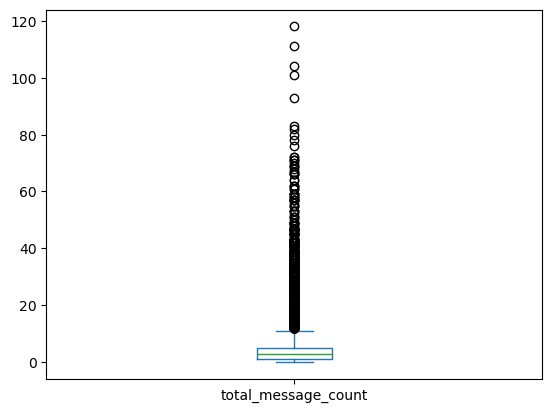

In [6]:
processed_data['total_message_count'].plot(kind = 'box')

In [11]:
processed_data['CONV_SECONDS'].describe()

count    1.579700e+04
mean     8.102905e+03
std      1.083141e+05
min      0.000000e+00
25%      8.000000e+00
50%      2.300000e+01
75%      2.350000e+02
max      5.518820e+06
Name: CONV_SECONDS, dtype: float64

In [90]:
processed_data[processed_data['CONV_SECONDS'] >= processed_data['CONV_SECONDS'].quantile(0.75)]

,CONVERSATION_ID,CONV_LAST_UPDATED_DTTM,CONVERSATION,HISTORY_MESSAGES,CONV_SECONDS,NEXT_NODE_ID,LAST_NODE_ID,LAST_NODE_TYPE,identity,skill_name,status,user_message_count,assistant_message_count,total_message_count
9,6cdf38f4-c31e-e4e2-f292-2a95a77bb176,2025-10-15 20:23:05.512592,{'context_id': '458f4c470783a1e2817b29060284d1...,"[{'role': 'assistant', 'text': 'Olá, Pedro! 👋 ...",9643,magic_help_skill_eval,magic_help_guide,speaker,maria95,magic_help_skill,WAITING_NODES,3,4,7
13,df3420fe-affb-9e25-4011-2baf513438c6,2025-11-16 04:12:47.222364,{'context_id': '8d372732c1b0f2e23350cc6dace8c6...,"[{'role': 'assistant', 'text': '¡Hola Jefferso...",3224,magic_help_skill_eval,magic_help_guide,speaker,xreid,magic_help_skill,WAITING_NODES,13,14,27
15,6e86fd2e-b5b5-df52-a6e4-8267c8bbacde,2025-10-31 17:17:08.746495,{'context_id': '684c46a310f1726c7d30ef6c985a37...,"[{'role': 'assistant', 'text': 'Olá Fellippo! ...",12163,magic_help_skill_eval,magic_help_guide,speaker,frankgray,magic_help_skill,WAITING_NODES,4,5,9
20,265e34b7-f26f-32cf-5d67-8c215e643200,2025-11-04 18:48:57.872836,{'context_id': '483f5be406dea86700a083e8ab91c9...,"[{'role': 'assistant', 'text': 'Olá, William! ...",5746,magic_help_skill_eval,magic_help_guide,speaker,icox,magic_help_skill,WAITING_NODES,6,7,13
29,45698393-a532-af85-7446-867efc4bf623,2025-10-17 02:59:46.152877,{'context_id': '6685d4e44fd9623e67fd34b64d3c1c...,"[{'role': 'assistant', 'text': '¡Hola Miguel! ...",546,magic_help_skill_eval,magic_help_guide,speaker,spenceamanda,magic_help_skill,WAITING_NODES,4,5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15761,dc2bf683-c005-41d5-36f8-161d97bfb889,2025-10-07 13:57:23.180314,{'context_id': '42f6e3e962aec8a404bd8d9d360f02...,"[{'role': 'assistant', 'text': '¡Hola Jairo! 👋...",236,magic_help_skill_eval,magic_help_guide,speaker,fred53,magic_help_skill,WAITING_NODES,2,3,5
15762,d57178b8-812c-a170-0f30-cd7e7793b099,2025-10-29 19:38:44.772849,{'context_id': 'cb3fd1510d675de514746552c81e13...,"[{'role': 'assistant', 'text': '¡Hola Juan! 👋 ...",185067,magic_help_skill_eval,magic_help_guide,speaker,wallaceheather,magic_help_skill,WAITING_NODES,3,4,7
15765,f68e49b3-96dc-de92-9bba-16c48540efc1,2025-11-05 12:30:41.844368,{'context_id': '55412b397a610ff5808bc4290b28c6...,"[{'role': 'assistant', 'text': 'Olá Vitor! 👋 S...",305,magic_help_skill_eval,magic_help_guide,speaker,jennifersilva,magic_help_skill,WAITING_NODES,2,3,5
15772,a075b5b7-22e1-e707-fe0d-d8d0ca447e2c,2025-10-28 20:23:44.032246,{'context_id': 'b2ea105fa05a3f626ce0a15bca7430...,"[{'role': 'assistant', 'text': '¡Hola, Felix! ...",682,__finish__,magic_help_skill_error,python,randy99,magic_help_skill,WAITING_NODES,2,2,4


<Axes: >

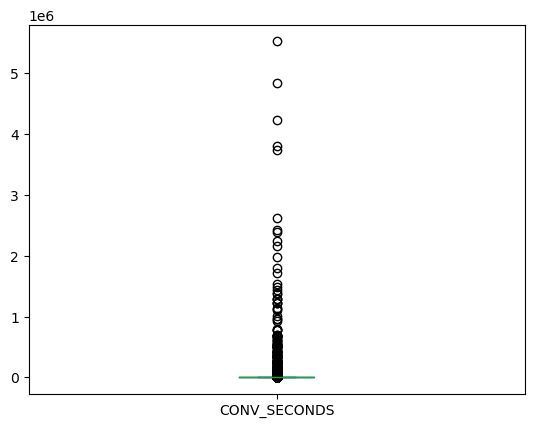

In [12]:
processed_data['CONV_SECONDS'].plot(kind = 'box')

## Conversations has different languages

In [ ]:
# Apply to the first user message of each conversation
processed_data['language'] = processed_data['HISTORY_MESSAGES'].apply(
    lambda msgs: get_language(next((m['text'] for m in msgs if m['role'] == 'assistant'), ""))
)

In [9]:
processed_data['language'].value_counts()

language
es         11702
pt          3863
unknown      231
en             1
Name: count, dtype: int64

### Español

In [40]:
j = random.randint(a = 1, b = 1000)
processed_data[processed_data['language'] == 'es']['HISTORY_MESSAGES'].values[j]

[{'role': 'assistant',
  'text': '¡Hola Florencia! 👋 Soy Magic Help, tu asistente para todo lo que necesites sobre Magic y Gen AI en Oz_land.\n\nVeo que venís usando varias herramientas de Gen AI a diario, como *Oz_land GPT* y *Windsurf*, aunque todavía no creaste *Skills* en Magic 🚀.\n\n¿Te gustaría conocer ejemplos de lo que podés hacer en Magic o querés ayuda con alguna idea puntual?',
  'conversation_id': 'aa22024d-a97b-3cca-b805-677feebb73ca',
  'metadata': {'has_next': False,
   'idx': 1,
   'node_id': 'magic_help_guide',
   'timestamp': '2025-10-24 18:31:43',
   'type': 'message'}},
 {'role': 'user',
  'text': 'Hola. Es posible integrar magic con MCP de figma por ejemplo?',
  'conversation_id': 'aa22024d-a97b-3cca-b805-677feebb73ca',
  'metadata': {'timestamp': '2025-10-24 18:33:45', 'type': 'message'}},
 {'role': 'assistant',
  'text': '¡Genial pregunta, Florencia! Por el momento, **no es posible integrar Magic con MCP** (Oz_land Collaboration Process) como, por ejemplo, en Fig

### Portugués

In [39]:
j = random.randint(a = 1, b = 1000)
processed_data[processed_data['language'] == 'pt']['HISTORY_MESSAGES'].values[j]

[{'role': 'assistant',
  'text': 'Olá, Jacqueline! 👋 Eu sou o Magic Help, seu assistente para tudo relacionado à plataforma Magic e inteligência artificial generativa no Oz_land.\n\nPercebi que você já criou algumas Skills como "jtamura" e "acessarsite", e está dando seus primeiros passos com ferramentas de GenAI aqui na companhia. 😊\n\nComo posso te ajudar hoje? Você gostaria de saber mais sobre o que a Magic pode oferecer ou já está desenvolvendo algo específico e precisa de apoio?',
  'conversation_id': '6091f4d5-20c1-2aaa-05ac-bc6f4aef770e',
  'metadata': {'node_id': 'magic_help_guide',
   'timestamp': '2025-10-07 12:51:48',
   'type': 'message'}}]

### Inglés

In [5]:
processed_data[processed_data['language'] == 'en']

,CONVERSATION_ID,CONV_LAST_UPDATED_DTTM,CONVERSATION,HISTORY_MESSAGES,CONV_SECONDS,NEXT_NODE_ID,LAST_NODE_ID,LAST_NODE_TYPE,identity,skill_name,status,user_message_count,assistant_message_count,total_message_count,language
6047,b7d8f4fd-26e5-c777-4d9f-dac003826b92,2025-11-20 15:06:52.108177,{'context_id': 'ff114b7066ae6464a5920b86c37030...,"[{'role': 'assistant', 'text': 'Hi Ivy Zhuang ...",7,magic_help_skill_eval,magic_help_guide,speaker,robert07,magic_help_skill,WAITING_NODES,0,1,1,en


# Save processed data

In [116]:
processed_data.to_csv("../data/processed_conversations.csv", index=False)
exploded_data.to_csv("../data/processed_exploded_conversations.csv", index=False)